### Notebook 4 — RFM Clustering (Phân khúc khách hàng)
**Người phụ trách:** Trần Tấn Lực — 52400055 — Pattern Mining Lead

**Bộ dữ liệu:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

---

**Input:** `Data/Processed/Customer_RFM.csv` 

**Output:** `Data/Interim/Customer_Segments_Sesult.csv` — Bảng gán nhãn phân khúc cho từng khách hàng.

---

**Mục lục:**
1. Đọc dữ liệu RFM + Khám phá phân phối
2. Chuẩn bị dữ liệu: log-transform và chuẩn hoá
3. Chọn số cụm k: Elbow Method và Silhouette Score
4. Chạy K-Means
5. Chạy K-Medoids (PAM)
6. So sánh phản biện K-Means vs K-Medoids
7. Đặt tên nghiệp vụ và diễn giải từng phân khúc
---


### 0. Chuẩn bị môi trường

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Xác định thư mục gốc project để Notebook có thể import Source/
PROJECT_NOW = Path.cwd()
if (PROJECT_NOW / "Source").exists():
    PROJECT_ROOT_TAM = PROJECT_NOW
else:
    PROJECT_ROOT_TAM = PROJECT_NOW.parent
sys.path.insert(0, str(PROJECT_ROOT_TAM))

from Source.Utils.IO import (load_csv, save_to_csv, get_project_root, PROCESSED_DATA_DIR, INTERIM_DATA_DIR, MODELS_DIR,)
from Source.Utils.Visualization import (set_plot_style, save_current_figure, PRIMARY_COLOR, SECONDARY_COLOR, ALERT_COLOR,)
from Source.RFM.Clustering import (prepare_rfm_features, run_kmeans, compute_elbow_scores, compute_silhouette_scores, run_kmedoids_pam, summarize_clusters, assign_segment_names,)

set_plot_style()
print(f"Thư mục gốc dự án: {get_project_root()}")

Thư mục gốc dự án: D:\Lilith\Customer-Analytics-for-E-Commerce


### 1. Đọc dữ liệu RFM + Khám phá phân phối

- Đọc `Customer_RFM.csv` — bảng RFM được tính trên toàn kỳ dữ liệu (snapshot = ngày giao
dịch cuối cùng). 

- Ta muốn mô tả khách hàng dựa trên toàn bộ lịch sử đã biết, không có yếu tố "dự đoán tương lai" nên không cần cắt snapshot sớm.

In [2]:
rfm_df = load_csv(PROCESSED_DATA_DIR / "Customer_RFM.csv")

print(f"Số khách hàng: {len(rfm_df):,}")
print(f"Các cột:  {list(rfm_df.columns)}\n")
rfm_df.describe().round(2)


Số khách hàng: 5,853
Các cột:  ['Customer ID', 'Recency', 'Frequency', 'Monetary']



,Customer ID,Recency,Frequency,Monetary
count,5853.00,5853.00,5853.00,5853.00
mean,15319.35,199.17,6.25,2916.34
std,1715.00,208.51,12.75,14305.79
min,12346.00,0.00,1.00,0.00
25%,13837.00,24.00,1.00,339.50
50%,15320.00,94.00,3.00,856.01
75%,16802.00,378.00,7.00,2240.90
max,18287.00,738.00,373.00,580987.04


**Nhận xét vì sao nên log-transform trước khi phân cụm:**

- Bảng thống kê cho thấy `Frequency` và đặc biệt là `Monetary` có phân phối lệch phải rõ rệt. `Frequency` có **median = 3** nhưng giá trị lớn nhất lên tới **373**; `Monetary` có **median = £ 856.01** và **75% = £ 2,240.90**, trong khi giá trị lớn nhất lên tới **£ 580,987.04**. Sự chênh lệch rất lớn giữa phần lớn khách hàng và một số ít khách hàng có giá trị giao dịch cao cho thấy các biến này chứa những giá trị cực đoan đáng kể.

- Vì K-Means và K-Medoids đều sử dụng khoảng cách để phân nhóm, các giá trị cực lớn có thể làm những điểm dữ liệu này tạo ảnh hưởng lớn đến khoảng cách giữa các khách hàng. Do đó, trong dự án này, nhóm sử dụng **`log1p` cho `Frequency` và `Monetary` trước khi chuẩn hóa**, nhằm giảm ảnh hưởng của các giá trị cực đoan và làm cho phân phối phù hợp hơn với bước phân cụm.

Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\6. RFM Distribution Before and After Log.png


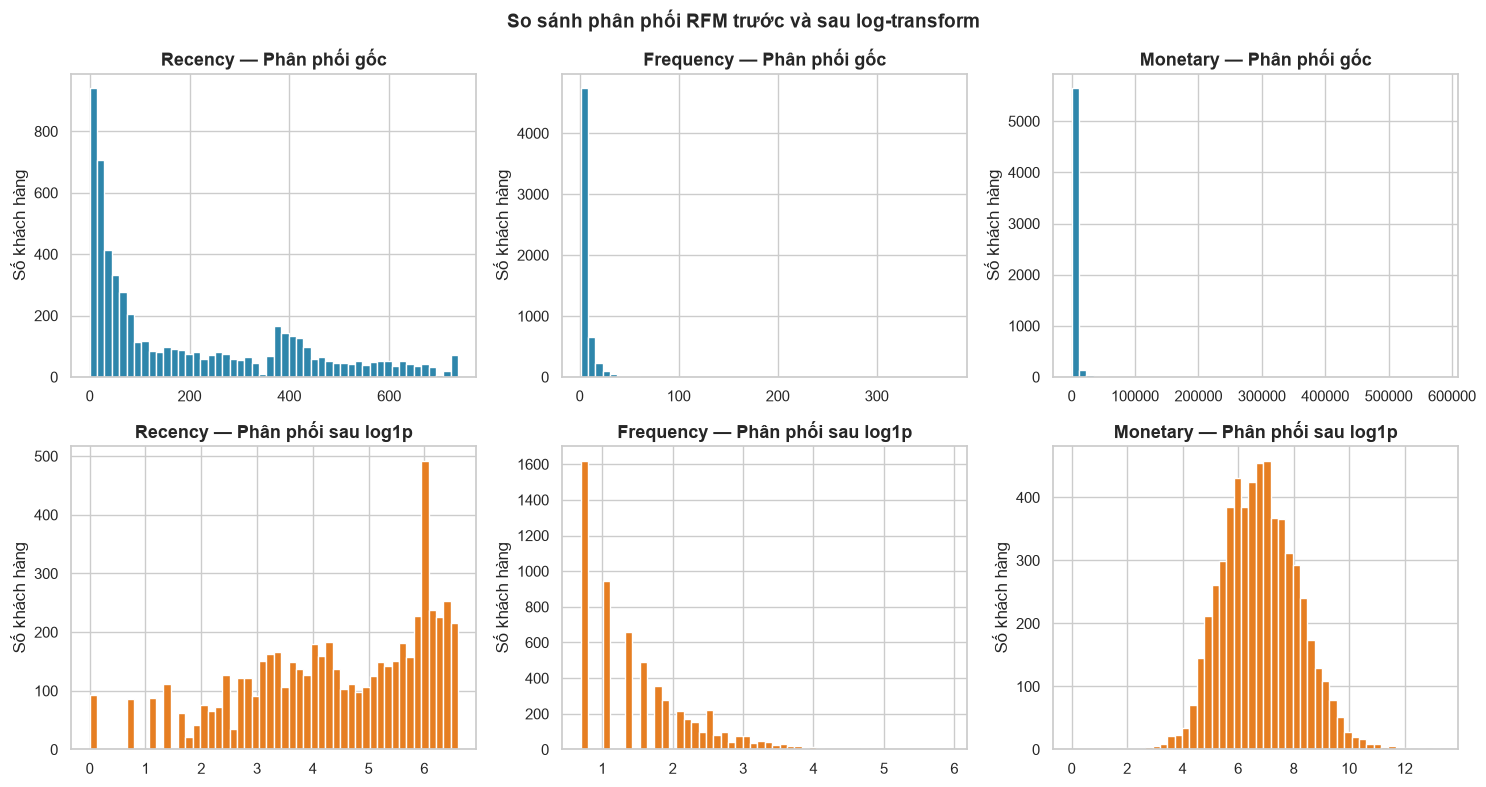

In [7]:
# So sánh phân phối RFM trước và sau log-transform

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col_index, column_name in enumerate(["Recency", "Frequency", "Monetary"]):
    # Hàng trên: phân phối gốc
    axes[0, col_index].hist(rfm_df[column_name], bins=50, color=PRIMARY_COLOR)
    axes[0, col_index].set_title( f"{column_name} — Phân phối gốc")
    axes[0, col_index].set_ylabel("Số khách hàng")

    # Hàng dưới: phân phối sau log1p
    axes[1, col_index].hist(np.log1p(rfm_df[column_name]), bins=50, color=SECONDARY_COLOR)
    axes[1, col_index].set_title(f"{column_name} — Phân phối sau log1p")
    axes[1, col_index].set_ylabel("Số khách hàng")

plt.suptitle("So sánh phân phối RFM trước và sau log-transform", fontsize=14, fontweight="bold")
plt.tight_layout()
save_current_figure("6. RFM Distribution Before and After Log.png")
plt.show()

**Nhận xét:** 
- Biểu đồ cho thấy `Frequency` và `Monetary` ở dạng gốc bị **lệch phải mạnh**, phần lớn quan sát tập trung ở vùng giá trị thấp trong khi một số ít khách hàng có giá trị rất lớn kéo dài trục phân phối. Sau `log1p`, độ phân tán của hai biến được nén lại đáng kể và hình dạng phân phối trở nên thuận lợi hơn cho bước chuẩn hóa và phân cụm.

- Đối với `Recency`, mặc dù biến này vẫn có dấu hiệu lệch phải, mức độ nén cần thiết chưa được kết luận chỉ từ biểu đồ. Trong phiên bản hiện tại, nhóm **giữ nguyên `Recency` và chỉ log-transform `Frequency` và `Monetary`** để tránh làm thay đổi trực tiếp ý nghĩa tuyến tính của số ngày kể từ lần mua gần nhất.


### 2. Chuẩn bị dữ liệu log-transform và chuẩn hoá

In [12]:
scaled_features, transformed_df = prepare_rfm_features(rfm_df)

print(f"\nKích thước ma trận đặc trưng: {scaled_features.shape}")
print(f"Trung bình sau chuẩn hoá (phải ~0): {scaled_features.mean(axis=0).round(6)}")
print(f"Độ lệch chuẩn sau chuẩn hoá (phải ~1): {scaled_features.std(axis=0).round(6)}")


[Prepare RFM Features] Đã log-transform các cột: ['Frequency', 'Monetary']
[Prepare RFM Features] Đã chuẩn hoá 5,853 khách hàng trên 3 đặc trưng: ['Recency', 'Frequency', 'Monetary']

Kích thước ma trận đặc trưng: (5853, 3)
Trung bình sau chuẩn hoá (phải ~0): [-0.  0. -0.]
Độ lệch chuẩn sau chuẩn hoá (phải ~1): [1. 1. 1.]


### 3. Chọn số cụm k — Elbow Method và Silhouette Score

Nhóm dùng **cả 2 phương pháp** thay vì chọn một con số tuỳ ý, vì mỗi phương pháp có ưu nhược riêng:

- **Elbow (Inertia):** Trực quan, dễ hiểu, nhưng việc xác định "điểm khuỷu tay" mang tính chủ quan — Nhiều khi đường cong mượt, không có khuỷu rõ ràng.

- **Silhouette:** cho ra một con số cụ thể để so sánh khách quan (chọn k có điểm cao nhất), nhưng tốn thời gian tính toán hơn nhiều do độ phức tạp O(n²).

In [16]:
K_RANGE = range(2, 11)

print("Tính Elbow (Inertia): ")
print("-" * 70)
elbow_df = compute_elbow_scores(scaled_features, k_range=K_RANGE)


Tính Elbow (Inertia): 
----------------------------------------------------------------------
[Compute Elbow Scores] k = 2: inertia = 8867.63
[Compute Elbow Scores] k = 3: inertia = 5710.00
[Compute Elbow Scores] k = 4: inertia = 4470.98
[Compute Elbow Scores] k = 5: inertia = 3646.28
[Compute Elbow Scores] k = 6: inertia = 3081.82
[Compute Elbow Scores] k = 7: inertia = 2741.67
[Compute Elbow Scores] k = 8: inertia = 2477.98
[Compute Elbow Scores] k = 9: inertia = 2293.72
[Compute Elbow Scores] k = 10: inertia = 2147.46


In [18]:
print("Tính Silhouette Score:")
print("-" * 70)
silhouette_df = compute_silhouette_scores(scaled_features, k_range=K_RANGE)


Tính Silhouette Score:
----------------------------------------------------------------------
[Compute Silhouette Scores] k = 2: silhouette = 0.4180
[Compute Silhouette Scores] k = 3: silhouette = 0.4017
[Compute Silhouette Scores] k = 4: silhouette = 0.3614
[Compute Silhouette Scores] k = 5: silhouette = 0.3647
[Compute Silhouette Scores] k = 6: silhouette = 0.3486
[Compute Silhouette Scores] k = 7: silhouette = 0.3356
[Compute Silhouette Scores] k = 8: silhouette = 0.3156
[Compute Silhouette Scores] k = 9: silhouette = 0.3116
[Compute Silhouette Scores] k = 10: silhouette = 0.2992


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\7. Elbow vs Silhouette.png


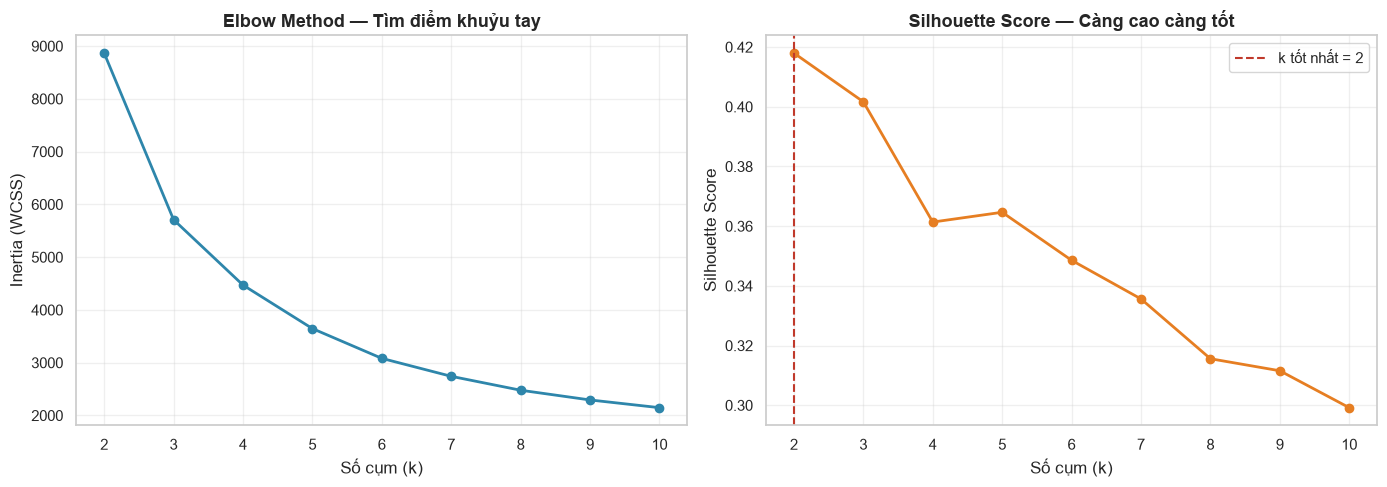

In [51]:
# Trực quan hóa Elbow và Silhouette

fig, (ax_elbow, ax_silhouette) = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Elbow
ax_elbow.plot(elbow_df["k"], elbow_df["inertia"], marker="o", color=PRIMARY_COLOR, linewidth=2)
ax_elbow.set_xlabel("Số cụm (k)")
ax_elbow.set_ylabel("Inertia (WCSS)")
ax_elbow.set_title("Elbow Method — Tìm điểm khuỷu tay")
ax_elbow.grid(True, alpha=0.3)


# Biểu đồ Silhouette
ax_silhouette.plot(silhouette_df["k"], silhouette_df["silhouette"], marker="o", color=SECONDARY_COLOR, linewidth=2)

# Tìm k có Silhouette cao nhất
best_k_silhouette = int(silhouette_df.loc[ silhouette_df["silhouette"].idxmax(), "k"])
best_score = silhouette_df["silhouette"].max()

# Đánh dấu k tốt nhất trên biểu đồ
ax_silhouette.axvline(x=best_k_silhouette, color=ALERT_COLOR, linestyle="--", label=f"k tốt nhất = {best_k_silhouette}")

ax_silhouette.set_xlabel("Số cụm (k)")
ax_silhouette.set_ylabel("Silhouette Score")
ax_silhouette.set_title("Silhouette Score — Càng cao càng tốt")
ax_silhouette.legend()
ax_silhouette.grid(True, alpha=0.3)

plt.tight_layout()
save_current_figure("7. Elbow vs Silhouette.png")
plt.show()

In [31]:
# Tổng hợp kết quả Elbow và Silhouette

# Ghép 2 kết quả theo số cụm k
selection_table = elbow_df.merge(silhouette_df, on="k")

# Tính mức Inertia giảm so với k trước
selection_table["Inertia_Giam_So_Voi_K_Truoc"] = (- selection_table["inertia"].diff()).round(2)

# Đổi tên cột để bảng dễ đọc và thuận tiện đưa vào báo cáo
selection_table = selection_table.rename(
    columns={
        "k"                          : "Số cụm (k)",
        "inertia"                    : "Inertia",
        "silhouette"                 : "Silhouette",
        "Inertia_Giam_So_Voi_K_Truoc": "Inertia giảm so với k trước",
    }
)

selection_table.round(4)

,Số cụm (k),Inertia,Silhouette,Inertia giảm so với k trước
0,2,8867.6267,0.4180,NaN
1,3,5710.0036,0.4017,3157.62
2,4,4470.9797,0.3614,1239.02
3,5,3646.2772,0.3647,824.70
4,6,3081.8155,0.3486,564.46
5,7,2741.6726,0.3356,340.14
6,8,2477.9770,0.3156,263.70
7,9,2293.7241,0.3116,184.25
8,10,2147.4617,0.2992,146.26


### **Quyết định chọn k**

- Quan sát hai tiêu chí kỹ thuật cho thấy Inertia giảm mạnh khi tăng `k` ở các giá trị nhỏ và sau đó giảm dần, cho thấy lợi ích của việc tăng thêm số cụm ngày càng nhỏ. Kết quả Silhouette đạt **0.4180 tại k = 2**, là giá trị cao nhất trong toàn bộ khoảng khảo sát từ `k = 2` đến `k = 10`.

- Tuy nhiên, xét mục tiêu Customer Segmentation của dự án, nhóm giới hạn phạm vi xem xét ở **3–5 cụm** để số lượng phân khúc vẫn đủ chi tiết cho việc diễn giải đặc điểm khách hàng và xây dựng các nhóm hành động marketing riêng biệt, đồng thời tránh tạo quá nhiều phân khúc khó triển khai.

- Trong phạm vi **3–5 cụm**, `k = 3` có điểm Silhouette cao nhất (**0.4017**), cao hơn `k = 4` (**0.3614**) và `k = 5` (**0.3647**). Vì vậy, nhóm **chọn k = 3** cho bước phân khúc khách hàng tiếp theo. Đây là quyết định kết hợp giữa kết quả đánh giá kỹ thuật và yêu cầu triển khai nghiệp vụ, thay vì lựa chọn chỉ dựa trên một chỉ số duy nhất.


In [36]:
# Chọn số cụm k theo Silhouette trong phạm vi nghiệp vụ
BUSINESS_K_RANGE = (3, 5)

candidates = silhouette_df[(silhouette_df["k"] >= BUSINESS_K_RANGE[0]) & (silhouette_df["k"] <= BUSINESS_K_RANGE[1])].copy()

if candidates.empty:
    raise ValueError(f"Không có giá trị k nào nằm trong khoảng {BUSINESS_K_RANGE[0]}–{BUSINESS_K_RANGE[1]}.")

CHOSEN_K = int(candidates.loc[candidates["silhouette"].idxmax(),"k"])
best_business_silhouette = candidates["silhouette"].max()

print(f"Số cụm được chọn: k = {CHOSEN_K}")
print(f"Silhouette = {best_business_silhouette:.4f}")

Số cụm được chọn: k = 3
Silhouette = 0.4017


### 4. Chạy K-Means

In [37]:
kmeans_labels, kmeans_model = run_kmeans(scaled_features, n_clusters=CHOSEN_K)

[Run K-Means] k = 3: inertia = 5710.00, kích thước các cụm = [2354, 1824, 1675]


### 5. Chạy K-Medoids (PAM)

In [39]:
# Chạy K-Medoids (PAM) với số cụm đã chọn

pam_labels, medoid_indices, pam_cost = run_kmedoids_pam(scaled_features, n_clusters=CHOSEN_K)

print(f"\nChỉ số dòng của các khách hàng được chọn làm MEDOID: {medoid_indices.tolist()}")
print("\nThông tin RFM của các khách hàng đại diện (MEDOID): ")
print("(Mỗi medoid là một khách hàng có thật trong dữ liệu, không phải điểm trung bình ảo như centroid của K-Means.)")

medoid_customers = rfm_df.iloc[medoid_indices][["Customer ID", "Recency", "Frequency", "Monetary",]]
medoid_customers

[Run K-Medoids PAM] Đã tính ma trận khoảng cách (5853, 5853) (~261 MB RAM).
[Run K-Medoids PAM] k = 3: hội tụ sau 5 vòng lặp, tổng chi phí = 5123.68, kích thước các cụm = [2283, 1899, 1671]

Chỉ số dòng của các khách hàng được chọn làm MEDOID: [2491, 5360, 1112]

Thông tin RFM của các khách hàng đại diện (MEDOID): 
(Mỗi medoid là một khách hàng có thật trong dữ liệu, không phải điểm trung bình ảo như centroid của K-Means.)


,Customer ID,Recency,Frequency,Monetary
2491,14880.0,76,3,690.59
5360,17792.0,466,2,368.35
1112,13481.0,45,11,3830.84


### 6. So sánh phản biện K-Means vs K-Medoids

In [49]:
# So sánh K-Means và K-Medoids PAM

from sklearn.metrics import (silhouette_score, adjusted_rand_score,)

# Silhouette Score trên cùng một dữ liệu đã chuẩn hóa
silhouette_kmeans = silhouette_score(scaled_features, kmeans_labels,)
silhouette_pam = silhouette_score(scaled_features, pam_labels,)

# Adjusted Rand Index (ARI):
# Đo mức độ tương đồng giữa hai cách phân cụm, có hiệu chỉnh ảnh hưởng của sự đồng thuận ngẫu nhiên.
agreement_score = adjusted_rand_score(kmeans_labels, pam_labels,)

# Tạo bảng so sánh
algorithm_comparison = pd.DataFrame({
    "Tiêu chí": [
        "Silhouette Score",
        "Kích thước các cụm",
        "Loại tâm cụm",
        "Khả năng chịu ảnh hưởng của Outlier",
    ],

    "K-Means": [
        round(silhouette_kmeans, 4),
        str(np.bincount( kmeans_labels).tolist()),
        "Centroid (Tâm cụm tính bằng trung bình)",
        "Nhạy cảm hơn với Outlier",
    ],

    "K-Medoids (PAM)": [
        round(silhouette_pam, 4),
        str(np.bincount( pam_labels).tolist()),
        "Medoid (Một khách hàng thực tế)",
        "Ít nhạy cảm hơn với Outlier",
    ],
})

# Đánh giá mức độ tương đồng giữa K-Means và K-Medoids
print(f"Mức độ tương đồng giữa 2 thuật toán (Adjusted Rand Index - ARI): {agreement_score:.4f}")

algorithm_comparison

Mức độ tương đồng giữa 2 thuật toán (Adjusted Rand Index - ARI): 0.9565


,Tiêu chí,K-Means,K-Medoids (PAM)
0,Silhouette Score,0.4017,0.4012
1,Kích thước các cụm,"[2354, 1824, 1675]","[2283, 1899, 1671]"
2,Loại tâm cụm,Centroid (Tâm cụm tính bằng trung bình),Medoid (Một khách hàng thực tế)
3,Khả năng chịu ảnh hưởng của Outlier,Nhạy cảm hơn với Outlier,Ít nhạy cảm hơn với Outlier


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\8. KMeans vs KMedoids.png


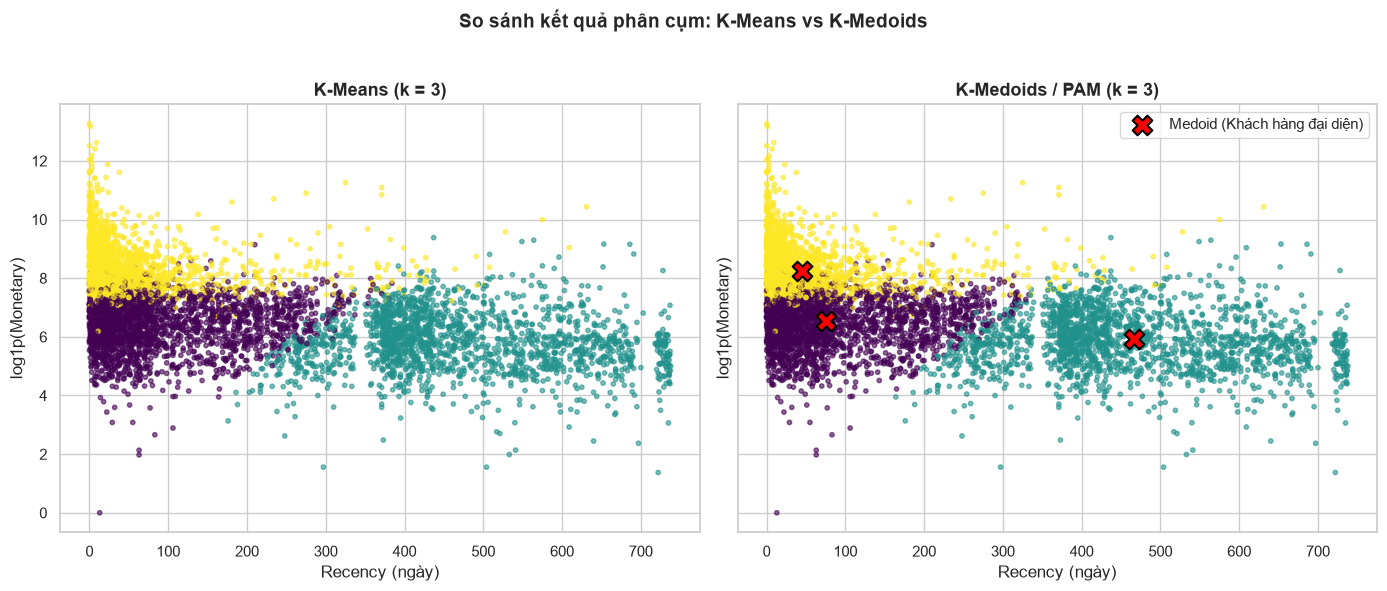

In [53]:
# Trực quan hóa K-Means và K-Medoids trên cùng hệ trục

# Dùng Recency và Monetary sau log1p
fig, (ax_kmeans, ax_pam) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True,)

# K-Means
ax_kmeans.scatter(transformed_df["Recency"], transformed_df["Monetary"], c=kmeans_labels, cmap="viridis", s=10, alpha=0.6,)
ax_kmeans.set_xlabel("Recency (ngày)")
ax_kmeans.set_ylabel("log1p(Monetary)")
ax_kmeans.set_title(f"K-Means (k = {CHOSEN_K})")


# K-Medoids / PAM
ax_pam.scatter(transformed_df["Recency"], transformed_df["Monetary"], c=pam_labels, cmap="viridis", s=10, alpha=0.6,)

# Đánh dấu các medoid
ax_pam.scatter(transformed_df.iloc[medoid_indices]["Recency"], transformed_df.iloc[medoid_indices]["Monetary"], c="red", s=200, marker="X", edgecolors="black", linewidths=1.5, label="Medoid (Khách hàng đại diện)",)

ax_pam.set_xlabel("Recency (ngày)")
ax_pam.set_ylabel("log1p(Monetary)")
ax_pam.set_title(f"K-Medoids / PAM (k = {CHOSEN_K})")
ax_pam.legend()

plt.suptitle("So sánh kết quả phân cụm: K-Means vs K-Medoids", fontsize=14, fontweight="bold",)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_current_figure("8. KMeans vs KMedoids.png")
plt.show()

#### **Nhận xét:**

- **Về chất lượng phân cụm (Silhouette):** Hai thuật toán cho kết quả rất gần nhau, với Silhouette **0.4017 đối với K-Means** và **0.4012 đối với K-Medoids**. Chênh lệch chỉ **0.0005**, cho thấy trên dữ liệu RFM sau bước log-transform và chuẩn hóa, hai phương pháp tạo ra chất lượng phân cụm tương đối tương đương theo tiêu chí Silhouette. Điều này cũng cho thấy tác động của các giá trị cực đoan đã được giảm bớt đáng kể sau bước tiền xử lý. Tuy nhiên, không nên kết luận rằng tiền xử lý đã “giải quyết hoàn toàn” vấn đề Outlier; K-Medoids vẫn có đặc tính ít nhạy cảm hơn với các điểm cực đoan do sử dụng Medoid thay vì Centroid.

- **Về khả năng diễn giải:** K-Medoids có một ưu điểm rõ ràng về mặt diễn giải: mỗi tâm cụm là **một khách hàng thực tế** với `Customer ID` cụ thể. Điều này giúp đội Marketing có thể xem hồ sơ RFM của một khách hàng đại diện để hình dung đặc điểm của cụm. Trong khi đó, Centroid của K-Means là một điểm trung bình trong không gian đặc trưng và có thể không tương ứng với một khách hàng thực tế.

- **Về mức độ tương đồng giữa hai phương pháp:** `Adjusted Rand Index (ARI) = 0.9565` cho thấy hai cách phân cụm có **mức độ tương đồng rất cao** trên tập khách hàng hiện tại. Kết quả này củng cố nhận định rằng K-Means và K-Medoids đang phát hiện một cấu trúc phân khúc tương đối giống nhau, mặc dù kích thước từng cụm không hoàn toàn trùng khớp.

- **Kết luận lựa chọn:** Nhóm sử dụng **K-Means** làm kết quả phân khúc chính. Lựa chọn này dựa trên ba cơ sở: 
    
    **(a)** Chất lượng phân cụm theo Silhouette gần tương đương với K-Medoids. 
    
    **(b)** K-Means không cần xây dựng ma trận khoảng cách toàn cặp nên phù hợp hơn với yêu cầu mở rộng dữ liệu.
    
    **(c)** ARI = 0.9565 cho thấy hai phương pháp tạo ra cấu trúc phân khúc rất tương đồng.


### 7. Đặt tên nghiệp vụ và diễn giải từng phân khúc

In [66]:
# Tổng hợp đặc điểm các phân khúc K-Means

cluster_summary = summarize_clusters(rfm_df, kmeans_labels)

cluster_summary_display = cluster_summary.rename(
    columns={
        "Cluster": "Cụm",
        "SoKhachHang": "Số khách hàng",
        "TyLePhanTram": "Tỷ lệ (%)",
        "Recency_TB": "Recency trung bình",
        "Frequency_TB": "Frequency trung bình",
        "Monetary_TB": "Monetary trung bình (£)",
    }
)

cluster_summary_display

,Cụm,Số khách hàng,Tỷ lệ (%),Recency trung bình,Frequency trung bình,Monetary trung bình (£)
0,0,2354,40.22,89.91,2.92,839.66
1,1,1824,31.16,470.36,1.79,542.12
2,2,1675,28.62,57.39,15.80,8420.25


In [68]:
segment_names = assign_segment_names(cluster_summary)

print("Tên nghiệp được gán cho từng cụm:\n")
for cluster_id, name in sorted(segment_names.items()):
    row = cluster_summary[cluster_summary["Cluster"] == cluster_id].iloc[0]
    print(f"Cụm {cluster_id} — {name}")
    print(f"   Số khách hàng : {int(row['SoKhachHang']):,} ({row['TyLePhanTram']}%)")
    print(f"   Recency TB    : {row['Recency_TB']:.0f} ngày")
    print(f"   Frequency TB  : {row['Frequency_TB']:.1f} hoá đơn")
    print(f"   Monetary TB   : £{row['Monetary_TB']:,.0f}\n")


Tên nghiệp được gán cho từng cụm:

Cụm 0 — Khách hàng trung thành
   Số khách hàng : 2,354 (40.22%)
   Recency TB    : 90 ngày
   Frequency TB  : 2.9 hoá đơn
   Monetary TB   : £840

Cụm 1 — Khách hàng có nguy cơ rời bỏ
   Số khách hàng : 1,824 (31.16%)
   Recency TB    : 470 ngày
   Frequency TB  : 1.8 hoá đơn
   Monetary TB   : £542

Cụm 2 — Khách VIP
   Số khách hàng : 1,675 (28.62%)
   Recency TB    : 57 ngày
   Frequency TB  : 15.8 hoá đơn
   Monetary TB   : £8,420



Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\9. Segment Profiles.png


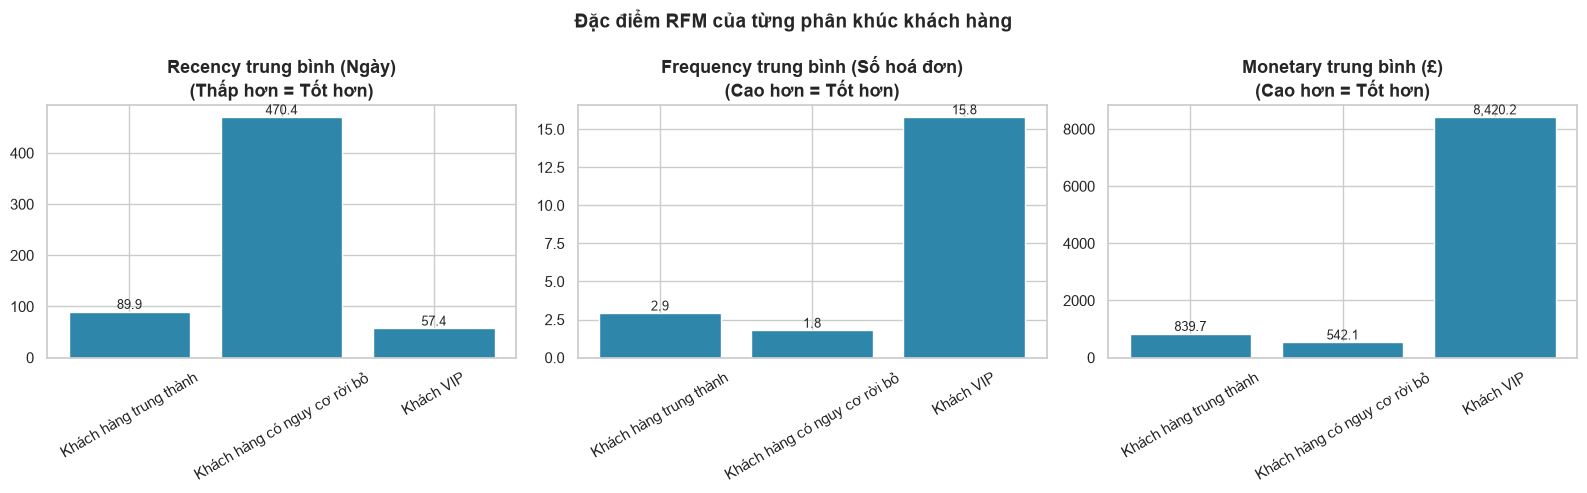

In [71]:
# Trực quan hóa hồ sơ RFM của từng phân khúc

cluster_summary["TenPhanKhuc"] = (cluster_summary["Cluster"].map(segment_names))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = [
    (
        "Recency_TB",
        "Recency trung bình (Ngày)\n"
        "(Thấp hơn = Tốt hơn)"
    ),
    (
        "Frequency_TB",
        "Frequency trung bình (Số hoá đơn)\n"
        "(Cao hơn = Tốt hơn)"
    ),
    (
        "Monetary_TB",
        "Monetary trung bình (£)\n"
        "(Cao hơn = Tốt hơn)"
    ),
]

for ax, (metric_column, metric_title) in zip(axes, metrics_to_plot):
    bars = ax.bar(cluster_summary["TenPhanKhuc"], cluster_summary[metric_column], color=PRIMARY_COLOR)
    ax.set_title(metric_title)
    ax.tick_params(axis="x", rotation=30)

    for bar, value in zip(bars, cluster_summary[metric_column]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:,.1f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Đặc điểm RFM của từng phân khúc khách hàng", fontsize=14, fontweight="bold")
plt.tight_layout()
save_current_figure("9. Segment Profiles.png")
plt.show()

#### **Đề xuất hành động cho từng phân khúc**

| Phân khúc                        | Đặc điểm RFM                                                                                                                                                                                                                                                      | Hành động đề xuất                                                                                                                                                                                                           |
| -------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Khách VIP**                    | Mua rất gần đây (`Recency ≈ 57 ngày`), tần suất cao (`Frequency ≈ 15.8` hóa đơn) và giá trị chi tiêu vượt trội (`Monetary ≈ £8,420`). Theo kết quả hiện tại, đây là nhóm có giá trị khách hàng cao nhất và đóng góp khoảng **79% tổng Monetary** của 3 phân khúc. | Tập trung chương trình giữ chân và chăm sóc khách hàng giá trị cao: ưu đãi độc quyền, quyền lợi thành viên, sản phẩm cao cấp và các chiến dịch bán thêm/bán chéo phù hợp.                                                   |
| **Khách trung thành**            | Mua khá gần đây (`Recency ≈ 90 ngày`), có mức Frequency trung bình (`≈ 2.9` hóa đơn) và Monetary ở mức trung bình (`≈ £840`).                                                                                                                                     | Khuyến khích tăng giá trị giỏ hàng thông qua **cross-sell/up-sell**, đặc biệt có thể kết hợp với các luật từ Market Basket Analysis của Thành viên B để đề xuất sản phẩm mua kèm.                                           |
| **Khách hàng có nguy cơ rời bỏ** | Đã lâu chưa quay lại (`Recency ≈ 470 ngày`), đồng thời có Frequency (`≈ 1.8`) và Monetary (`≈ £542`) thấp nhất trong ba nhóm.                                                                                                                                     | Thực hiện chiến dịch tái kích hoạt như email nhắc lại, ưu đãi có thời hạn hoặc gợi ý sản phẩm phù hợp với lịch sử mua trước đây. Nên ưu tiên kiểm tra phản hồi của nhóm này trước khi tăng chi phí tiếp thị trên diện rộng. |


In [79]:
#  Xuất kết quả phân khúc khách hàng
segments_result = rfm_df[["Customer ID", "Recency", "Frequency", "Monetary",]].copy()

# Nhãn cụm K-Means chính thức
segments_result["Cluster"] = kmeans_labels

# Tên phân khúc nghiệp vụ
segments_result["TenPhanKhuc"] = (segments_result["Cluster"].map(segment_names))

# Nhãn cụm K-Medoids để đối chiếu
segments_result["Cluster_KMedoids"] = pam_labels

# Kiểm tra
print(f"Số khách hàng đã gán nhãn: {len(segments_result):,}")
print("\nPhân bố theo phân khúc:")
print(segments_result["TenPhanKhuc"].value_counts())

segments_result = segments_result.rename(
    columns={
        "Customer ID": "Customer ID",
        "Recency": "Recency",
        "Frequency": "Frequency",
        "Monetary": "Monetary",
        "Cluster": "Cluster",
        "TenPhanKhuc": "Tên phân khúc",
        "Cluster_KMedoids": "Cluster K-Medoids",
    }
)


output_path = (INTERIM_DATA_DIR / "Customer_Segments_Result.csv")
save_to_csv(segments_result, output_path)

Số khách hàng đã gán nhãn: 5,853

Phân bố theo phân khúc:
TenPhanKhuc
Khách hàng trung thành          2354
Khách hàng có nguy cơ rời bỏ    1824
Khách VIP                       1675
Name: count, dtype: int64
Đã lưu file: D:\Lilith\Customer-Analytics-for-E-Commerce\Data\Interim\Customer_Segments_Result.csv  (Số dòng: 5,853 | Số cột: 7)


In [84]:
# Lưu và kiểm tra model K-Means

# Đảm bảo thư mục Models/ tồn tại
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Lưu model K-Means đã train
kmeans_model_path = (MODELS_DIR / "KMeans_RFM.pkl")

joblib.dump(kmeans_model, kmeans_model_path)

print(f"Đã lưu model: {kmeans_model_path}")


# Kiểm tra có thể load lại model hay không
loaded_model = joblib.load(kmeans_model_path)
print(f"Load lại thành công — Số cụm của model: {loaded_model.n_clusters}")

Đã lưu model: D:\Lilith\Customer-Analytics-for-E-Commerce\Models\KMeans_RFM.pkl
Load lại thành công — Số cụm của model: 3


In [89]:
# Tự kiểm tra lại file vừa xuất
verify_df = pd.read_csv(INTERIM_DATA_DIR / "Customer_Segments_Result.csv")
print(f"Shape: {verify_df.shape}")
print(f"Các cột: {list(verify_df.columns)}")
verify_df.head(6)


Shape: (5853, 7)
Các cột: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Tên phân khúc', 'Cluster K-Medoids']


,Customer ID,Recency,Frequency,Monetary,Cluster,Tên phân khúc,Cluster K-Medoids
0,12346.0,325,3,77352.96,2,Khách VIP,2
1,12347.0,1,8,4921.53,2,Khách VIP,2
2,12348.0,74,5,1658.40,0,Khách hàng trung thành,0
3,12349.0,18,3,3678.69,0,Khách hàng trung thành,0
4,12350.0,309,1,294.40,1,Khách hàng có nguy cơ rời bỏ,1
5,12351.0,374,1,300.93,1,Khách hàng có nguy cơ rời bỏ,1
